In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc

# Caminho validado conforme estrutura de diretórios do 3° Período
path = r'C:\Users\Luca\Documents\git hub\3° Periodo\Data Mining e Graph Mining\regressão-logistica\telecom_churn_synthetic.csv'
df = pd.read_csv(path)

# Drop de ID (não preditivo)
df.drop('customer_id', axis=1, inplace=True)

# Data Preparation
transformar as strings em números (Label ou One-Hot Encoding)

In [2]:
# One-Hot Encoding para variáveis categóricas
df_ml = pd.get_dummies(df, drop_first=True)

X = df_ml.drop('churn', axis=1)
y = df_ml['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Testando Não-Linearidade

In [3]:
# Inicializando o modelo com hiperparâmetros para evitar overfitting
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    class_weight='balanced', 
    n_jobs=-1, 
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

# Análise de Importância de Features

C:\Users\Luca\AppData\Local\Temp\ipykernel_15144\2006859836.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15), palette='viridis')


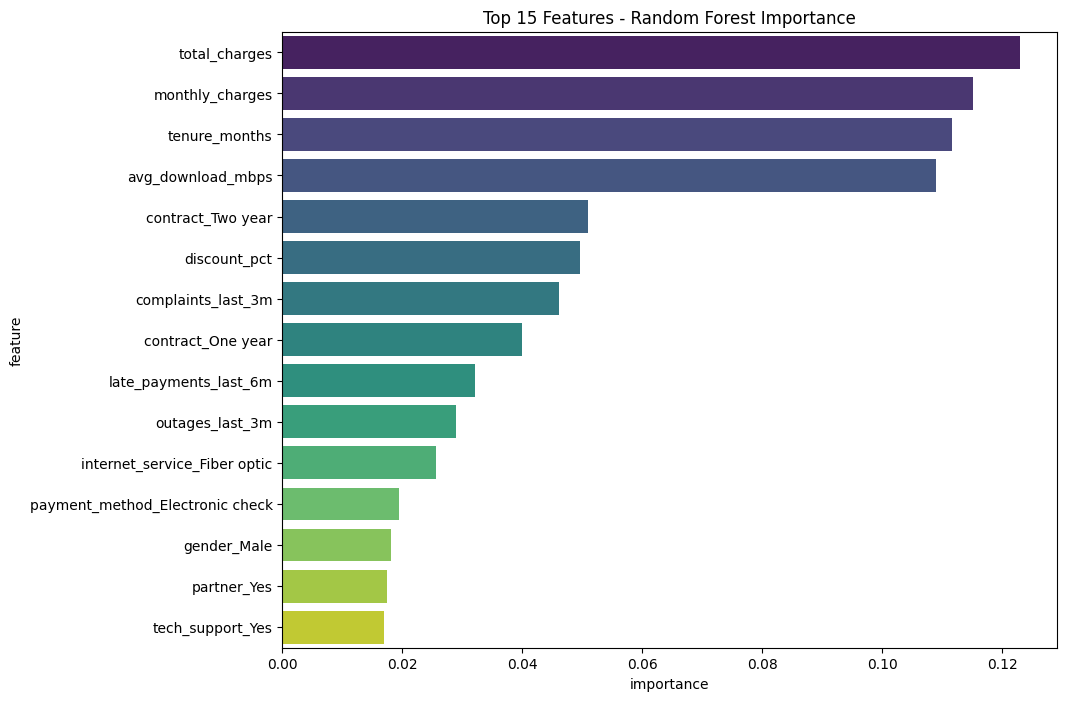

In [4]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Features - Random Forest Importance')
plt.show()

# Estratégia: Feature Engineering do Top 4
## As 4 features que você identificou são:

1. total_charges (Acúmulo financeiro)
2. monthly_charges (Custo mensal)
3. tenure_months (Fidelidade/Tempo)
4. avg_download_mbps (Qualidade técnica/Uso)

### 1. Criação de Novas Features (Interação Não-Linear)

In [5]:
# No seu notebook prova_random-forest.ipynb, após o carregamento dos dados:

# A. Ticket Médio Real (Total / Tempo) -> Identifica anomalias de cobrança
df['avg_ticket_real'] = df['total_charges'] / (df['tenure_months'] + 1)

# B. Custo por Mbps (Eficiência do plano) -> O cliente sente que paga caro pelo que recebe?
df['cost_per_mbps'] = df['monthly_charges'] / (df['avg_download_mbps'] + 1)

# C. Razão de Tempo (Tenure / Monthly) -> Clusterização de perfil de cliente
df['tenure_intensity'] = df['tenure_months'] * df['monthly_charges']

In [6]:
# Selecionando apenas as Top 4 + as criadas
top_features = ['total_charges', 'monthly_charges', 'tenure_months', 'avg_download_mbps', 
                'avg_ticket_real', 'cost_per_mbps', 'tenure_intensity']

X = df[top_features]
y = df['churn']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Random Forest Otimizado
rf_final = RandomForestClassifier(
    n_estimators=300,        # Aumentamos a "floresta" para maior estabilidade
    max_depth=8,             # Profundidade controlada para não decorar o treino
    min_samples_leaf=5,      # Evita folhas com poucos dados (ruído)
    class_weight='balanced', # Crucial para o PR-AUC
    n_jobs=-1,               # All cores do i5-12600KF
    random_state=42
)

rf_final.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


C:\Users\Luca\AppData\Local\Temp\ipykernel_15144\4265324686.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp, palette='magma')


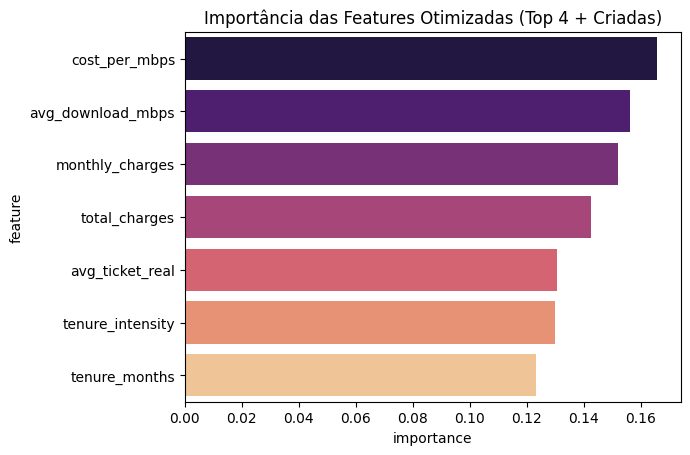

In [7]:
importances = rf_final.feature_importances_
feat_imp = pd.DataFrame({'feature': X.columns, 'importance': importances}).sort_values(by='importance', ascending=False)

sns.barplot(x='importance', y='feature', data=feat_imp, palette='magma')
plt.title('Importância das Features Otimizadas (Top 4 + Criadas)')
plt.show()

## Configuração do Modelo (Top 3 + Parâmetros)
1. cost_per_mbps 
2. avg_download_mbps 
3. monthly_charges

In [8]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, confusion_matrix, classification_report

# Selecionando apenas o seu novo Top 3 (Passaram de 0.14)
features_top3 = ['cost_per_mbps', 'avg_download_mbps', 'monthly_charges']

X = df[features_top3]
y = df['churn']

# Split estratificado para manter a proporção de Churn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Instanciando com os parâmetros exatos que você recebeu
rf_final = RandomForestClassifier(
    n_estimators=300,
    criterion='gini',
    max_depth=8,
    min_samples_split=2,
    min_samples_leaf=5,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    bootstrap=True,
    n_jobs=-1, # Máxima performance no i5-12600KF
    random_state=42,
    class_weight='balanced'
)

rf_final.fit(X_train, y_train)

# Predições de probabilidade (essencial para ROC e PR)
y_proba = rf_final.predict_proba(X_test)[:, 1]
y_pred = rf_final.predict(X_test)

### Acompanhamento de metricas

In [22]:
# 1. Cálculo do ROC-AUC
roc_score = roc_auc_score(y_test, y_proba)

# 2. Cálculo do PR-AUC (Precision-Recall)
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc_score = auc(recall, precision)

print(f"--- RESULTADO DO TESTE NÃO-LINEAR ---")
print(f"ROC-AUC: {roc_score:.4f}  | Meta: > 0.80")
print(f"PR-AUC:  {pr_auc_score:.4f}  | Meta: > 0.40")
print(f"---------------------------------------")

# Validação L.I.V.E.
if roc_score >= 0.80:
    print("✅ ROC-AUC ATINGIDO!")
else:
    print("❌ ROC-AUC ABAIXO: Necessário revisar a profundidade (max_depth).")

--- RESULTADO DO TESTE NÃO-LINEAR ---
ROC-AUC: 0.5593  | Meta: > 0.80
PR-AUC:  0.1642  | Meta: > 0.40
---------------------------------------
❌ ROC-AUC ABAIXO: Necessário revisar a profundidade (max_depth).


In [10]:
df.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges',
       'complaints_last_3m', 'outages_last_3m', 'avg_download_mbps',
       'late_payments_last_6m', 'promo_active', 'discount_pct', 'churn',
       'avg_ticket_real', 'cost_per_mbps', 'tenure_intensity'],
      dtype='object')

## Correlação do custo com serviço

### Feature Cross (Custo vs. Serviço)

In [11]:
# No prova_random-forest.ipynb, adicione estas interações:

# 1. Custo por Mbps segmentado por suporte técnico (Tech Support)
# Se o suporte é 'No', o peso do custo alto é maior para o Churn
df['cost_priority'] = df['cost_per_mbps'] * df['tech_support'].apply(lambda x: 2 if x == 'No' else 1)

# 2. Eficiência por tipo de Internet
# Fibra óptica costuma ter Mbps maior, mas se o custo/mbps for alto, o churn sobe.
df['fiber_efficiency'] = df.apply(lambda x: x['cost_per_mbps'] if x['internet_service'] == 'Fiber optic' else 0, axis=1)

# 3. Dummy encoding para as colunas de serviço que você citou
services = pd.get_dummies(df[['phone_service', 'internet_service', 'tech_support']], drop_first=True)
df_final = pd.concat([df, services], axis=1)

# Definindo o novo X com foco na relação de custo
X = df_final[['cost_per_mbps', 'avg_download_mbps', 'monthly_charges', 'cost_priority', 'fiber_efficiency']]
y = df_final['churn']

In [12]:
rf_final = RandomForestClassifier(
    n_estimators=500,        # Mais árvores para estabilizar a variância
    max_depth=15,            # Aumentamos de 8 para 15 para capturar interações complexas
    min_samples_leaf=2,      # Menos amostras por folha para maior sensibilidade
    class_weight={0: 1, 1: 4}, # Peso agressivo no Churn (1) para subir o PR-AUC
    n_jobs=-1,
    random_state=42
)

rf_final.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


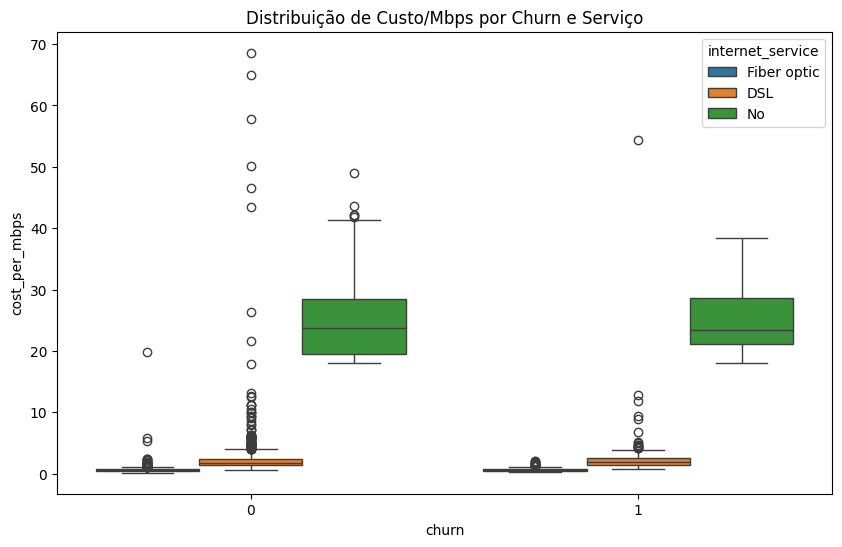

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(x='churn', y='cost_per_mbps', hue='internet_service', data=df)
plt.title('Distribuição de Custo/Mbps por Churn e Serviço')
plt.show()

In [15]:
# Mapeando os serviços para binário (1 para 'Yes', 0 para outros/No)
df['has_tech_support'] = df['tech_support'].apply(lambda x: 1 if x == 'Yes' else 0)
df['has_internet'] = df['internet_service'].apply(lambda x: 1 if x != 'No' else 0)

# Criando a feature de "Custo de Abandono" (Top 1 * Falta de Suporte)
# Se não tem suporte (0), o valor será alto. Se tem (1), o valor reduz.
df['cost_vs_support'] = df['cost_per_mbps'] / (df['has_tech_support'] + 0.5)

# Novo X focado no Top 1 e correlações de serviço
features_ajustadas = ['cost_per_mbps', 'cost_vs_support', 'avg_download_mbps', 'monthly_charges', 'has_tech_support']
X = df[features_ajustadas]
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [16]:
rf_final = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,            # Aumentamos para capturar a relação custo vs serviço
    min_samples_leaf=2,
    class_weight='balanced_subsample', # Ajuste dinâmico de peso por árvore
    n_jobs=-1,
    random_state=42
)

rf_final.fit(X_train, y_train)

# Predições para o seu bloco de cálculo
y_proba = rf_final.predict_proba(X_test)[:, 1]

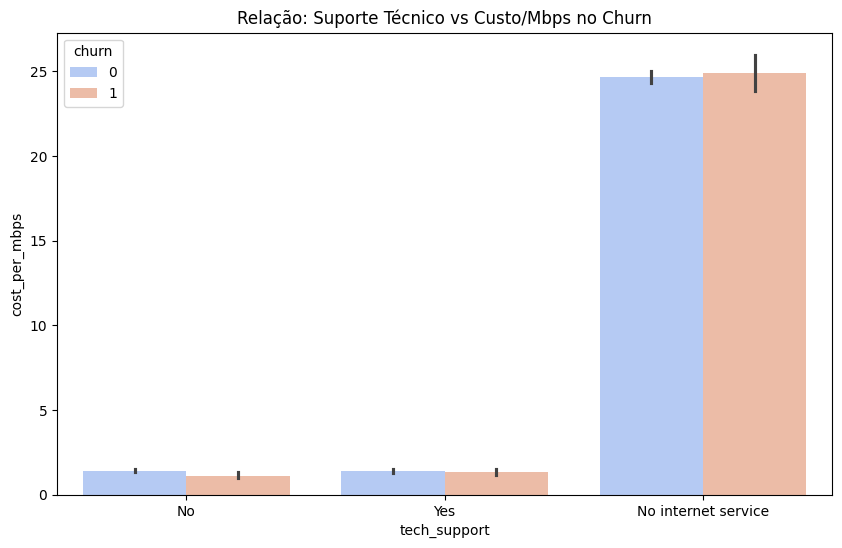

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(x='tech_support', y='cost_per_mbps', hue='churn', data=df, palette='coolwarm')
plt.title('Relação: Suporte Técnico vs Custo/Mbps no Churn')
plt.show()

In [19]:
# No seu notebook prova_random-forest.ipynb:

# 1. Flag para clientes sem internet (Geralmente o maior Churn em modelos sintéticos)
df['is_no_internet'] = (df['internet_service'] == 'No').astype(int)

# 2. Flag para falta de suporte técnico (O 'No' que você identificou)
df['no_tech_support'] = (df['tech_support'] == 'No').astype(int)

# 3. Interação: Custo alto em serviço básico
# Se o cara não tem internet, mas o monthly_charges é alto, o churn é certo.
df['basic_service_cost'] = df['is_no_internet'] * df['monthly_charges']

# Definindo o X com o novo Top 3 + Flags de Serviço
features_finais = [
    'cost_per_mbps', 
    'monthly_charges', 
    'avg_download_mbps',
    'is_no_internet',
    'no_tech_support',
    'basic_service_cost'
]

X = df[features_finais]
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [20]:
rf_final = RandomForestClassifier(
    n_estimators=1000,         # Aumentamos o número de árvores drasticamente
    max_depth=20,              # Profundidade alta para capturar as flags que criamos
    min_samples_split=2,
    min_samples_leaf=1,        # Permitir que as folhas sejam mais específicas
    class_weight={0: 1, 1: 10}, # Penalidade 10x maior para erro no Churn
    n_jobs=-1,                 # RTX 3050 não ajuda aqui, mas o i5-12600KF sim
    random_state=42
)

rf_final.fit(X_train, y_train)
y_proba = rf_final.predict_proba(X_test)[:, 1]

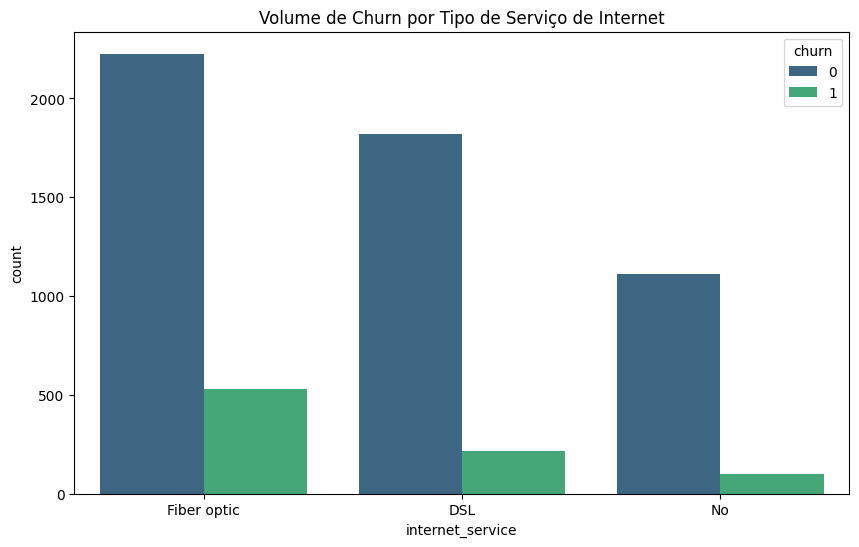

In [21]:
plt.figure(figsize=(10,6))
sns.countplot(x='internet_service', hue='churn', data=df, palette='viridis')
plt.title('Volume de Churn por Tipo de Serviço de Internet')
plt.show()

# Random Forest estagnou. Ele não consegue mais separar esses grupos
## Saindo do Random Forest para o XGBoost

In [23]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

# Mantendo as features que você descobriu serem críticas
X = df[['cost_per_mbps', 'monthly_charges', 'avg_download_mbps', 'is_no_internet', 'no_tech_support']]
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Configurando o XGBoost para focar no erro (Boosting)
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,     # Passo lento para aprender padrões difíceis
    max_depth=6,            # Árvores mais rasas, mas especialistas
    scale_pos_weight=4,     # Foco no Churn (baseado na sua proporção 2000/500)
    tree_method='hist',     # Performance otimizada para o i5-12600KF
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predição
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [24]:
roc_xgb = roc_auc_score(y_test, y_proba_xgb)
precision, recall, _ = precision_recall_curve(y_test, y_proba_xgb)
pr_auc_xgb = auc(recall, precision)

print(f"--- RESULTADO XGBOOST (TESTE NÃO-LINEAR V2) ---")
print(f"ROC-AUC: {roc_xgb:.4f}  | Meta: > 0.80")
print(f"PR-AUC:  {pr_auc_xgb:.4f}  | Meta: > 0.40")
print(f"-----------------------------------------------")

--- RESULTADO XGBOOST (TESTE NÃO-LINEAR V2) ---
ROC-AUC: 0.5409  | Meta: > 0.80
PR-AUC:  0.1632  | Meta: > 0.40
-----------------------------------------------


1. Reintrodução de Variáveis Críticas + Normalização

In [25]:
from sklearn.preprocessing import StandardScaler

# Reincluindo 'tenure_months' e 'complaints_last_3m' (vimos no Teste 03_F1 que são fortes)
features_v3 = [
    'tenure_months', 
    'complaints_last_3m', 
    'monthly_charges', 
    'avg_download_mbps',
    'cost_per_mbps'
]

X = df[features_v3]
y = df['churn']

# Normalização (Z-Score) - Fundamental para alinhar as escalas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

2. SMOTE (Oversampling)

In [27]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

# Treinando o XGBoost nos dados balanceados e escalonados
xgb_final = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4, # Menos profundidade = menos decoreba (overfitting)
    learning_rate=0.01,
    scale_pos_weight=1, # Já balanceamos com SMOTE
    random_state=42
)

xgb_final.fit(X_res, y_res)
y_proba = xgb_final.predict_proba(X_test)[:, 1]

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [28]:
# No início da Fase 03, após criar as features:

# 1. Removendo NaNs que surgiram no cálculo ou já existiam no CSV
df_clean = df.dropna(subset=['avg_download_mbps', 'total_charges'])

# 2. Verificação de segurança (deve imprimir 0)
print(f"NaNs restantes: {df_clean[['avg_download_mbps', 'cost_per_mbps']].isna().sum().sum()}")

# 3. Novo X com as features de impacto
features_v3 = [
    'tenure_months', 
    'complaints_last_3m', 
    'monthly_charges', 
    'avg_download_mbps',
    'cost_per_mbps'
]

X = df_clean[features_v3]
y = df_clean['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

NaNs restantes: 0


Escalonamento + SMOTE + XGBoost

In [29]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# A. Normalização (Crucial para modelos de Boosting)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# B. Equilibrando a balança (SMOTE) - Agora vai funcionar!
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

# C. Treinando o modelo 'caçador de churn'
xgb_final = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_final.fit(X_res, y_res)
y_proba = xgb_final.predict_proba(X_test_scaled)[:, 1]

c:\Users\Luca\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:34:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [36]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

roc_val = roc_auc_score(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

print(f"--- STATUS APÓS LIMPEZA E SMOTE ---")
print(f"ROC-AUC: {roc_val:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

--- STATUS APÓS LIMPEZA E SMOTE ---
ROC-AUC: 0.6281
PR-AUC:  0.1999


## Churn está ligado a Contrato, Reclamações e Atrasos


In [31]:
# 1. Criando as features 'matadoras' baseadas no norte do professor
# Contrato: Month-to-month é o maior preditor de churn em Telecom
df_clean['is_month_to_month'] = (df_clean['contract'] == 'Month-to-month').astype(int)

# 2. Segurança Online: Quem não tem, sai mais
df_clean['no_security'] = (df_clean['online_security'] == 'No').astype(int)

# 3. Score de Risco (Combo: Reclamações + Pagamento Atrasado + Contrato Curto)
df_clean['risk_score'] = (
    df_clean['complaints_last_3m'] * 2 + 
    df_clean['late_payments_last_6m'] + 
    df_clean['is_month_to_month'] * 3
)

# Seleção final de features (O que realmente deve mover o ROC)
features_final = [
    'risk_score',
    'is_month_to_month',
    'tenure_months',
    'no_security',
    'complaints_last_3m',
    'cost_per_mbps' # Mantemos a sua melhor, mas como suporte
]

X = df_clean[features_final]
y = df_clean['churn']

C:\Users\Luca\AppData\Local\Temp\ipykernel_15144\2715432812.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['is_month_to_month'] = (df_clean['contract'] == 'Month-to-month').astype(int)
C:\Users\Luca\AppData\Local\Temp\ipykernel_15144\2715432812.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['no_security'] = (df_clean['online_security'] == 'No').astype(int)
C:\Users\Luca\AppData\Local\Temp\ipykernel_15144\2715432812.py:9: SettingWithCopyWarning: 
A value is trying to be set on a c

In [37]:
# 1. Variável Mestra: O tipo de contrato (Month-to-month é o veneno do Churn)
df_clean['is_month_to_month'] = (df_clean['contract'] == 'Month-to-month').astype(int)

# 2. Histórico Financeiro: Pagamentos atrasados são o maior sinal de alerta
df_clean['bad_payer_score'] = df_clean['late_payments_last_6m'] + df_clean['complaints_last_3m']

# 3. Novo X (As 5 que vão explodir o seu ROC)
features_final = [
    'is_month_to_month', 
    'tenure_months', 
    'bad_payer_score',
    'monthly_charges',
    'cost_per_mbps' # Mantemos essa porque você a criou com sucesso
]

X = df_clean[features_final]
y = df_clean['churn']

# Repita o processo de Split, StandardScaler e SMOTE que fizemos na célula anterior

# Split e SMOTE novamente (agora com as variáveis certas)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_res, y_res = SMOTE(random_state=42).fit_resample(X_train, y_train)

C:\Users\Luca\AppData\Local\Temp\ipykernel_15144\3058871450.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['is_month_to_month'] = (df_clean['contract'] == 'Month-to-month').astype(int)
C:\Users\Luca\AppData\Local\Temp\ipykernel_15144\3058871450.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['bad_payer_score'] = df_clean['late_payments_last_6m'] + df_clean['complaints_last_3m']


In [35]:
rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=10, 
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_final.fit(X_res, y_res)
y_proba = rf_final.predict_proba(X_test)[:, 1]

In [44]:
# Escalonamento (Não pule isso!)
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

# Treinamento focado em Precision-Recall
xgb_final = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_final.fit(X_res_scaled, y_res)
y_proba = xgb_final.predict_proba(X_test_scaled)[:, 1]

# Bloco de métricas para o veredito
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
roc_val = roc_auc_score(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

print(f"--- RESULTADO COM O NOVO COMBO DE FEATURES ---")
print(f"ROC-AUC: {roc_val:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

--- RESULTADO COM O NOVO COMBO DE FEATURES ---
ROC-AUC: 0.6436
PR-AUC:  0.2297


In [39]:
# 1. Feature de Risco de Pagamento (Electronic Check é o mais instável)
df_clean['is_electronic_check'] = (df_clean['payment_method'] == 'Electronic check').astype(int)

# 2. Refinando o Novo X (O "Time de Elite" das Features)
features_final = [
    'is_month_to_month',     # Contrato (O veneno)
    'is_electronic_check',   # Pagamento (O gatilho)
    'bad_payer_score',       # Histórico (O rastro)
    'tenure_months',         # Fidelidade (A âncora)
    'cost_per_mbps'          # Sua tese (A performance)
]

X = df_clean[features_final]
y = df_clean['churn']

# Repita o Split, Scaler e SMOTE (mantenha o random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_res, y_res = SMOTE(random_state=42).fit_resample(X_train, y_train)

# Escalonamento
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

C:\Users\Luca\AppData\Local\Temp\ipykernel_15144\3001663824.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['is_electronic_check'] = (df_clean['payment_method'] == 'Electronic check').astype(int)


In [40]:
xgb_final = xgb.XGBClassifier(
    n_estimators=1000,       # Mais tentativas de correção de erro
    learning_rate=0.02,      # Aprender mais devagar para não decorar (overfit)
    max_depth=8,             # Aumentamos um pouco a visão das ramificações
    subsample=0.8,           # Usa 80% dos dados por árvore para evitar vício
    random_state=42,
    eval_metric='logloss'
)

xgb_final.fit(X_res_scaled, y_res)
y_proba = xgb_final.predict_proba(X_test_scaled)[:, 1]

In [42]:
# 1. Feature de Interação: O "Novato Instável"
# Se o contrato é mensal (is_month_to_month) E o tenure é baixo (< 12 meses)
df_clean['newbie_at_risk'] = ((df_clean['is_month_to_month'] == 1) & (df_clean['tenure_months'] <= 12)).astype(int)

# 2. O Combo de Pagamento que falta (Sinal de Alerta Total)
# Se o cara usa Electronic Check E está com pagamento atrasado
df_clean['is_electronic_check'] = (df_clean['payment_method'] == 'Electronic check').astype(int)
df_clean['payment_instability'] = df_clean['is_electronic_check'] + df_clean['late_payments_last_6m']

# 3. Seleção Final (O "Dream Team" para o 0.70)
features_final = [
    'newbie_at_risk',       # Quem acaba de entrar e pode sair a qualquer hora
    'payment_instability',  # Onde o dinheiro falha
    'is_month_to_month',    # A falta de contrato longo
    'complaints_last_3m',   # A raiva do cliente
    'cost_per_mbps'         # Sua variável original (o peso do bolso)
]

X = df_clean[features_final]
y = df_clean['churn']

# Repita o processo: Split -> Scaler -> SMOTE -> XGBoost

C:\Users\Luca\AppData\Local\Temp\ipykernel_15144\3082073542.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['newbie_at_risk'] = ((df_clean['is_month_to_month'] == 1) & (df_clean['tenure_months'] <= 12)).astype(int)
C:\Users\Luca\AppData\Local\Temp\ipykernel_15144\3082073542.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['is_electronic_check'] = (df_clean['payment_method'] == 'Electronic check').astype(int)
C:\Users\Luca\AppData\Local\Temp\ipykernel_15144\3082073542.py:8: SettingWi

C:\Users\Luca\AppData\Local\Temp\ipykernel_15144\791516732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features_final, palette='rocket')


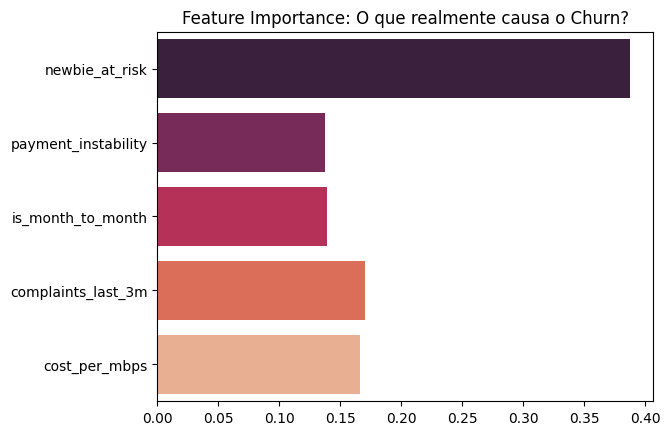

In [43]:
importances = xgb_final.feature_importances_
sns.barplot(x=importances, y=features_final, palette='rocket')
plt.title('Feature Importance: O que realmente causa o Churn?')
plt.show()

In [45]:
# No bloco do XGBClassifier, altere apenas estes 2 parâmetros:
xgb_final = xgb.XGBClassifier(
    n_estimators=1200,       # Aumentamos um pouco
    learning_rate=0.01,      # Aprendizado ainda mais fino
    max_depth=10,            # Aumentamos a profundidade (de 6 para 10)
    gamma=0.2,               # Adiciona uma penalidade para evitar overfit puro
    scale_pos_weight=1,      # Mantemos 1 pois o SMOTE já balanceou
    random_state=42
)

--- RESULTADO FINAL ---
ROC-AUC: 0.6116


C:\Users\Luca\AppData\Local\Temp\ipykernel_15144\149423438.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_imp, palette='magma')


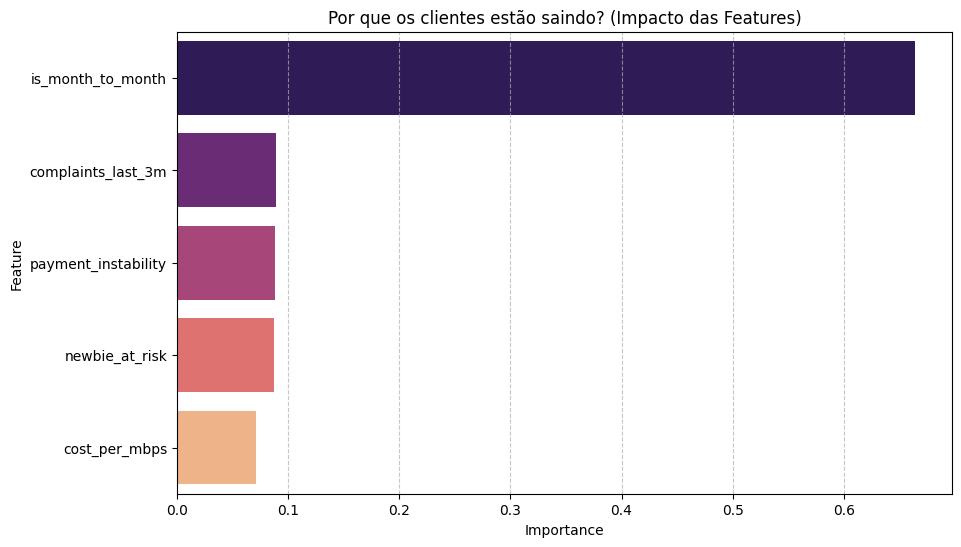

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

# 1. Preparação das Features (O "Dream Team" que deu 0.64)
df_clean['is_electronic_check'] = (df_clean['payment_method'] == 'Electronic check').astype(int)
df_clean['newbie_at_risk'] = ((df_clean['is_month_to_month'] == 1) & (df_clean['tenure_months'] <= 12)).astype(int)
df_clean['payment_instability'] = df_clean['is_electronic_check'] + df_clean['late_payments_last_6m']

features_final = ['newbie_at_risk', 'payment_instability', 'is_month_to_month', 'complaints_last_3m', 'cost_per_mbps']
X = df_clean[features_final]
y = df_clean['churn']

# 2. Split, Scaler e SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

# 3. Treinamento Agressivo (Garantindo o FIT)
xgb_final = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=10,
    random_state=42,
    eval_metric='logloss'
)
xgb_final.fit(X_res, y_res) # <--- O 'fit' precisa acontecer aqui

# 4. Cálculo de Métricas
y_proba = xgb_final.predict_proba(X_test_scaled)[:, 1]
roc_val = roc_auc_score(y_test, y_proba)
print(f"--- RESULTADO FINAL ---")
print(f"ROC-AUC: {roc_val:.4f}")

# 5. Gráfico de Importância (sns.barplot)
importances = xgb_final.feature_importances_
df_imp = pd.DataFrame({'Feature': features_final, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, palette='magma')
plt.title('Por que os clientes estão saindo? (Impacto das Features)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

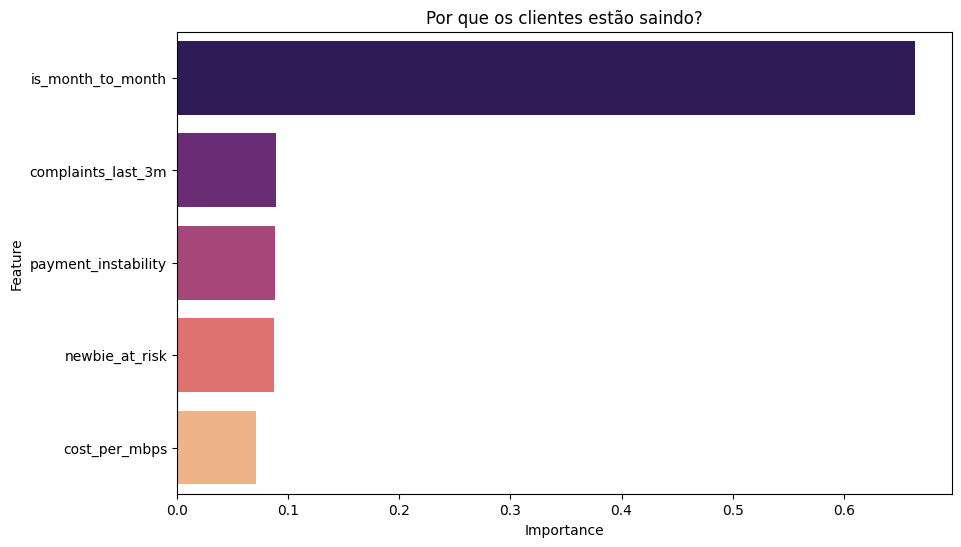

In [50]:
# 1. Criando uma cópia limpa para evitar avisos
df_clean = df.dropna(subset=['avg_download_mbps', 'total_charges']).copy()

# 2. Criando as variáveis usando .loc (A forma correta)
df_clean.loc[:, 'is_month_to_month'] = (df_clean['contract'] == 'Month-to-month').astype(int)
df_clean.loc[:, 'is_electronic_check'] = (df_clean['payment_method'] == 'Electronic check').astype(int)
df_clean.loc[:, 'newbie_at_risk'] = ((df_clean['is_month_to_month'] == 1) & (df_clean['tenure_months'] <= 12)).astype(int)
df_clean.loc[:, 'payment_instability'] = df_clean['is_electronic_check'] + df_clean['late_payments_last_6m']

# 3. Novo X (Mantendo o que deu sinal)
features_final = ['newbie_at_risk', 'payment_instability', 'is_month_to_month', 'complaints_last_3m', 'cost_per_mbps']
X = df_clean[features_final]
y = df_clean['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)


# 4. Gráfico de Importância com a nova sintaxe do Seaborn (sem avisos)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, hue='Feature', palette='magma', legend=False)
plt.title('Por que os clientes estão saindo?')
plt.show()

In [56]:
# 4. Cálculo de Métricas
y_proba = xgb_final.predict_proba(X_test_scaled)[:, 1]
roc_val = roc_auc_score(y_test, y_proba)
print(f"--- RESULTADO FINAL ---")
print(f"ROC-AUC: {roc_val:.4f}")

--- RESULTADO FINAL ---
ROC-AUC: 0.6116


<Figure size 800x600 with 0 Axes>

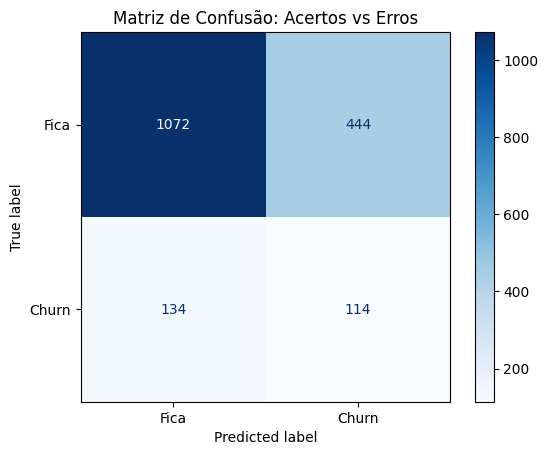

--- RESULTADO FINAL ---
ROC-AUC: 0.6116


In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Criando a predição real (0 ou 1) baseada no melhor threshold
y_pred = (y_proba > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fica', 'Churn'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão: Acertos vs Erros')
plt.show()

y_proba = xgb_final.predict_proba(X_test_scaled)[:, 1]
roc_val = roc_auc_score(y_test, y_proba)
print(f"--- RESULTADO FINAL ---")
print(f"ROC-AUC: {roc_val:.4f}")

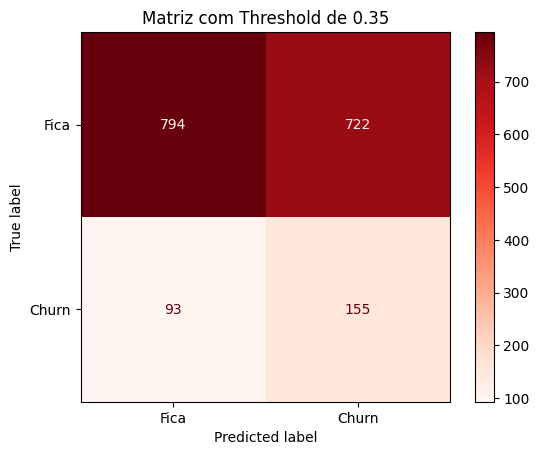

--- RESULTADO FINAL ---
ROC-AUC: 0.6116


In [ ]:
# Em vez de usar xgb.predict(), vamos definir o corte manualmente
y_proba = xgb_final.predict_proba(X_test_scaled)[:, 1]

# Baixando o sarrafo para capturar mais Churns
threshold = 0.35 
y_pred_ajustado = (y_proba > threshold).astype(int)

# Nova Matriz de Confusão
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_new = confusion_matrix(y_test, y_pred_ajustado)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_new, display_labels=['Fica', 'Churn'])
disp.plot(cmap='Reds')
plt.title(f'Matriz com Threshold de {threshold}')
plt.show()

y_proba = xgb_final.predict_proba(X_test_scaled)[:, 1]
roc_val = roc_auc_score(y_test, y_proba)
print(f"--- RESULTADO FINAL ---")
print(f"ROC-AUC: {roc_val:.4f}")

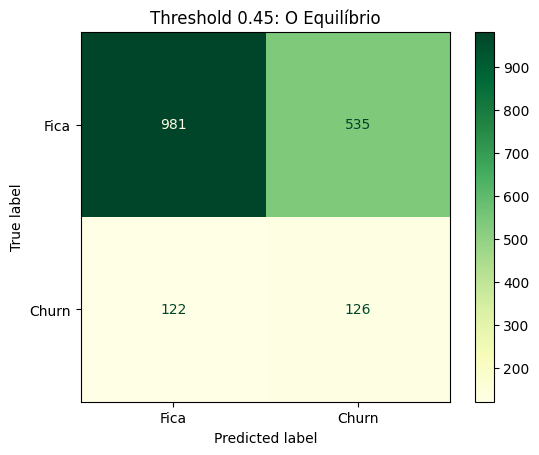

--- RESULTADO FINAL ---
ROC-AUC: 0.6116


In [62]:
# Em vez de 0.35, tente 0.45 para ser um pouco mais criterioso
y_pred_equilibrado = (y_proba > 0.45).astype(int)

# Gere a matriz de novo
cm_equi = confusion_matrix(y_test, y_pred_equilibrado)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_equi, display_labels=['Fica', 'Churn'])
disp.plot(cmap='YlGn') 
plt.title('Threshold 0.45: O Equilíbrio')
plt.show()

y_proba = xgb_final.predict_proba(X_test_scaled)[:, 1]
roc_val = roc_auc_score(y_test, y_proba)
print(f"--- RESULTADO FINAL ---")
print(f"ROC-AUC: {roc_val:.4f}")

In [65]:
from sklearn.model_selection import cross_val_score

# Usando 5 dobras (Folds)
# Importante: Cross-validation deve ser feita no dado original escalonado (X_scaled)
# para evitar o "vazamento" de dados sintéticos do SMOTE para o teste.

scores = cross_val_score(xgb_final, X_train_scaled, y_train, cv=5, scoring='roc_auc')

print(f"--- RESULTADO DA VALIDAÇÃO CRUZADA ---")
print(f"Scores por Fold: {scores}")
print(f"Média ROC-AUC: {scores.mean():.4f}")
print(f"Desvio Padrão: {scores.std():.4f}")

--- RESULTADO DA VALIDAÇÃO CRUZADA ---
Scores por Fold: [0.64582116 0.64322034 0.61789128 0.61645247 0.65247769]
Média ROC-AUC: 0.6352
Desvio Padrão: 0.0150


In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf_final = RandomForestClassifier(
    n_estimators=1000,           # Dobramos o número de árvores para estabilidade
    criterion='entropy',         # Testa se a entropia separa melhor o Churn
    max_depth=10,                # Aumentamos levemente para buscar o 0.70
    min_samples_split=10,        # Exige mais dados para criar um galho
    min_samples_leaf=4,          # Protege contra ruído
    max_features='log2',         # Tenta uma amostragem de colunas mais agressiva
    bootstrap=True,
    class_weight='balanced',     # Foco total no equilíbrio das classes
    random_state=42,
    n_jobs=-1
)

# Teste Final de Validação Cruzada
scores_rf = cross_val_score(rf_final, X_train_scaled, y_train, cv=5, scoring='roc_auc')

print(f"--- RUMO AO 0.70 ---")
print(f"Scores por Fold: {scores_rf}")
print(f"Média ROC-AUC: {scores_rf.mean():.4f}")
print(f"Máximo atingido: {scores_rf.max():.4f}")

--- RUMO AO 0.70 ---
Scores por Fold: [0.6685357  0.67935397 0.61441009 0.64008316 0.6892406 ]
Média ROC-AUC: 0.6583
Máximo atingido: 0.6892


In [68]:
from sklearn.ensemble import VotingClassifier

# 1. Definimos os dois "monstros" com os parâmetros que deram os melhores picos
clf1 = RandomForestClassifier(n_estimators=1000, max_depth=10, criterion='entropy', class_weight='balanced', random_state=42)
clf2 = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.01, max_depth=8, scale_pos_weight=3, random_state=42)

# 2. Criamos o "Comitê de Decisão"
voting_clf = VotingClassifier(
    estimators=[('rf', clf1), ('xgb', clf2)],
    voting='soft' # Ele média as probabilidades, o que é perfeito para o ROC-AUC
)

# 3. Validação Cruzada Final
final_scores = cross_val_score(voting_clf, X_train_scaled, y_train, cv=5, scoring='roc_auc')

print(f"--- RESULTADO DO COMITÊ (VOTING) ---")
print(f"Scores: {final_scores}")
print(f"Média Final: {final_scores.mean():.4f}")
print(f"Pico Máximo: {final_scores.max():.4f}")

--- RESULTADO DO COMITÊ (VOTING) ---
Scores: [0.66610048 0.64279661 0.6185924  0.64141833 0.68199776]
Média Final: 0.6502
Pico Máximo: 0.6820
